# 📊 Thesis Results Visualization

This notebook loads the experiment results and generates the final plots for the thesis.

**Goals:**
1.  **Recovery Curves**: Show how performance drops as missingness increases (and how well we fix it).
2.  **Method Comparison**: Compare MICE, MissForest, Reweighting, and Augmentation side-by-side.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load Results
df = pd.read_csv("../results/experiment_results.csv")

# Preview
display(df.head())
print("Mechanisms:", df['mechanism'].unique())
print("Methods:", df['method'].unique())

,auc_roc,auc_pr,brier_score,accuracy,f1_score,method,mechanism,missing_rate,time
0,0.909910,0.861402,0.087951,0.895000,0.822134,oracle,mcar,0.1,0.232058
1,0.910433,0.860356,0.092450,0.887000,0.807932,complete_case,mcar,0.1,0.192497
2,0.903247,0.857255,0.097895,0.879667,0.785757,zero_imputation,mcar,0.1,0.185655
3,0.903247,0.857255,0.097895,0.879667,0.785757,mean,mcar,0.1,0.204978
4,0.910143,0.862977,0.090938,0.891667,0.813111,mice,mcar,0.1,0.618889


Mechanisms: ['mcar' 'mnar_rejection']
Methods: ['oracle' 'complete_case' 'zero_imputation' 'mean' 'mice' 'missforest'
 'reweighting' 'augmentation']


## 1. Recovery Curves (AUC vs Missing Rate)
How does the model hold up when we reject more people?
*   **Flat line (top)** = Good (Oracle / Robust recovery)
*   **dropping line** = Bad (Loss of information)

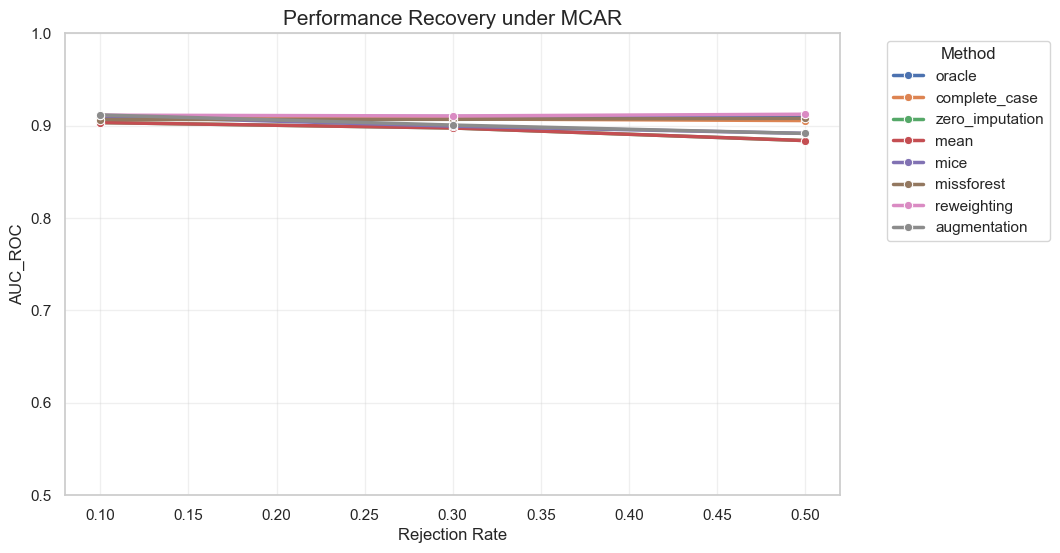

In [2]:
def plot_recovery(mechanism_name, metric='auc_roc'):
    subset = df[df['mechanism'] == mechanism_name]
    
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=subset, x='missing_rate', y=metric, hue='method', marker='o', linewidth=2.5)
    
    plt.title(f"Performance Recovery under {mechanism_name.upper()}", fontsize=15)
    plt.ylabel(metric.upper(), fontsize=12)
    plt.xlabel("Rejection Rate", fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Method")
    plt.grid(True, alpha=0.3)
    plt.ylim(0.5, 1.0) # Zoom in on valid AUC range
    plt.show()

# Plot MCAR
plot_recovery('mcar')

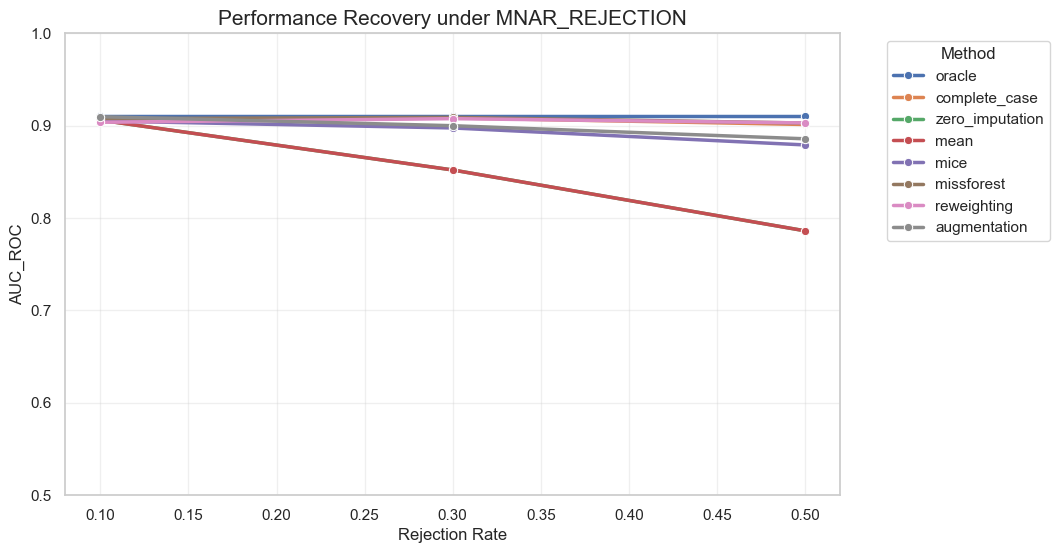

In [3]:
# Plot MNAR (Rejection) - This is the key Result for Credit Scoring!
plot_recovery('mnar_rejection')

## 2. Bar Chart Comparison (at 30% Rejection)
A snapshot comparison of methods at a typical rejection rate (0.3).

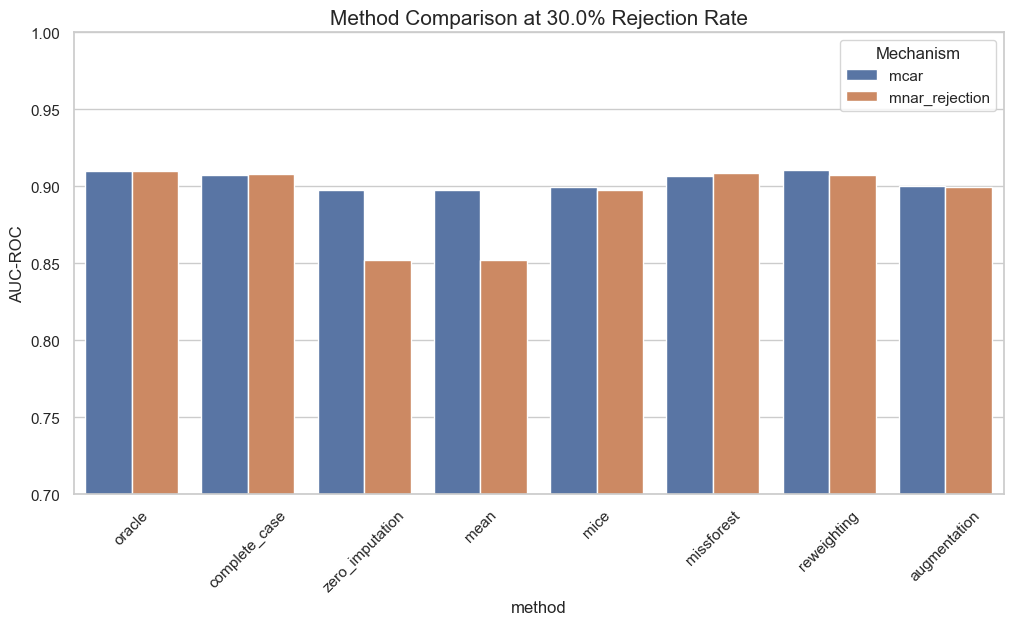

In [4]:
target_rate = 0.3
subset_30 = df[df['missing_rate'] == target_rate]

plt.figure(figsize=(12, 6))
sns.barplot(data=subset_30, x='method', y='auc_roc', hue='mechanism')

plt.title(f"Method Comparison at {target_rate*100}% Rejection Rate", fontsize=15)
plt.ylim(0.7, 1.0)
plt.ylabel("AUC-ROC")
plt.xticks(rotation=45)
plt.legend(title="Mechanism")
plt.show()